# Capítulo 2 — Ajuste de modelos a dados

*Como descobrir os parâmetros de um modelo a partir de medições reais.*

No Capítulo 1, todo modelo já vinha com os parâmetros prontos: dizíamos "$k=0{,}2$" ou "$r=0{,}5$, $K=200$" e simulávamos. Mas de onde vêm esses números? Na prática, **ninguém nos entrega os parâmetros** — nós os estimamos a partir de dados experimentais: contagens de células, concentrações medidas no laboratório, leituras de um sensor.

Este capítulo trata exatamente disso: dado um conjunto de medições e um modelo, **como encontrar os parâmetros que fazem o modelo passar o mais perto possível dos dados?** É o chamado *problema inverso*, e a ferramenta clássica para resolvê-lo é o **método dos mínimos quadrados**.

Vamos do caso mais simples (ajustar uma reta) até o mais poderoso (ajustar uma EDO inteira a dados), sempre com teoria, exemplo no papel e código em Python. No fim, faremos a ponte com a ideia de **máxima verossimilhança**, que abre o Capítulo 3 (calibração bayesiana).

## Preparando o ambiente

Além das bibliotecas do Capítulo 1, vamos usar o módulo de otimização do SciPy:

| Ferramenta | Para quê |
|---|---|
| `numpy`, `matplotlib` | contas, vetores e gráficos |
| `scipy.integrate.solve_ivp` | resolver EDOs (do Capítulo 1) |
| `scipy.optimize.curve_fit` | ajuste não linear de uma fórmula a dados |
| `scipy.optimize.least_squares` | minimizar resíduos — útil para ajustar EDOs |

Para que os resultados sejam reprodutíveis, fixamos a semente do gerador de números aleatórios (usado para criar dados sintéticos com ruído).

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import curve_fit, least_squares

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.size"] = 12
plt.rcParams["axes.grid"] = True

rng = np.random.default_rng(42)   # gerador reprodutivel: mesma "semente", mesmos dados
print("Ambiente pronto.")

Ambiente pronto.


## 1. O problema direto e o problema inverso

Vale separar dois tipos de pergunta:

- **Problema direto** (Capítulo 1): *conheço o modelo e os parâmetros; quero a solução.* Damos $r$ e $K$, e o `solve_ivp` devolve a curva.
- **Problema inverso** (este capítulo): *conheço os dados e a forma do modelo; quero os parâmetros.* Temos pontos medidos e a equação logística, e procuramos o $r$ e o $K$ que melhor os explicam.

O problema inverso é o que mais aparece na ciência aplicada, porque é assim que ligamos teoria e experimento. E ele quase nunca tem resposta "exata": os dados têm ruído, o modelo é uma simplificação e várias combinações de parâmetros podem parecer razoáveis. Por isso falamos em **melhor ajuste**, não em solução única.

Falta combinar o que significa "melhor". É aí que entram os resíduos.

## 2. Resíduos: a distância entre o modelo e os dados

Suponha que medimos pares $(x_i, y_i)$, com $i=1,\dots,n$, e que o modelo prevê, para cada $x_i$, um valor $\hat{y}_i$. O **resíduo** é a diferença entre o que medimos e o que o modelo previu:

$$
e_i = y_i - \hat{y}_i.
$$

Um resíduo positivo quer dizer que o modelo ficou *abaixo* do dado; negativo, que ficou *acima*. Um ajuste perfeito teria todos os resíduos iguais a zero — algo que praticamente nunca acontece com dados reais.

Queremos os parâmetros que deixam os resíduos **pequenos como um todo**. Mas "como um todo" precisa virar um número só, para podermos compará-lo entre escolhas de parâmetros. Esse número é a função de custo.

## 3. Por que *quadrados*?

A escolha clássica é somar os resíduos **ao quadrado**:

$$
S(\text{parâmetros}) = \sum_{i=1}^{n} e_i^{\,2} = \sum_{i=1}^{n}\left(y_i - \hat{y}_i\right)^2.
$$

Por que elevar ao quadrado, em vez de somar os resíduos ou seus valores absolutos?

- Somar os resíduos *com sinal* não serve: erros para cima e para baixo se cancelariam, e um ajuste péssimo poderia dar soma zero.
- O quadrado **elimina o sinal** (tudo fica positivo) e, de quebra, **penaliza mais os erros grandes**: um resíduo de $4$ pesa $16$, enquanto dois resíduos de $2$ pesam só $8$ no total. O ajuste fica, então, intolerante a desvios grandes.
- Além disso, a soma de quadrados é uma função *suave* dos parâmetros, o que torna a minimização tratável — no caso linear, ela tem até fórmula fechada.

O **método dos mínimos quadrados** é, em uma frase: *escolher os parâmetros que minimizam $S$*. Geometricamente, é procurar o fundo do "vale" da função de custo.

## 4. O caso mais simples: ajustar uma reta

Quando o modelo é uma reta,

$$
\hat{y} = a + b\,x,
$$

os parâmetros são o coeficiente linear $a$ e a inclinação $b$. A função de custo fica

$$
S(a,b) = \sum_{i=1}^{n}\left(y_i - a - b\,x_i\right)^2.
$$

Para achar o mínimo, derivamos $S$ em relação a $a$ e a $b$ e igualamos a zero. Isso dá as **equações normais**, cuja solução é

$$
b = \frac{\sum (x_i-\bar{x})(y_i-\bar{y})}{\sum (x_i-\bar{x})^2}, \qquad a = \bar{y} - b\,\bar{x},
$$

onde $\bar{x}$ e $\bar{y}$ são as médias. Repare na elegância: para a reta, o melhor ajuste sai de uma fórmula direta, sem tentativa e erro. Como consequência, a reta ajustada sempre passa pelo ponto médio $(\bar{x},\bar{y})$.

Na prática, deixamos o NumPy fazer a conta com `np.polyfit`, mas vale calcular "à mão" uma vez para ver que dá no mesmo.

A mao:    a = 1.515,  b = 0.897
polyfit:  a = 1.515,  b = 0.897


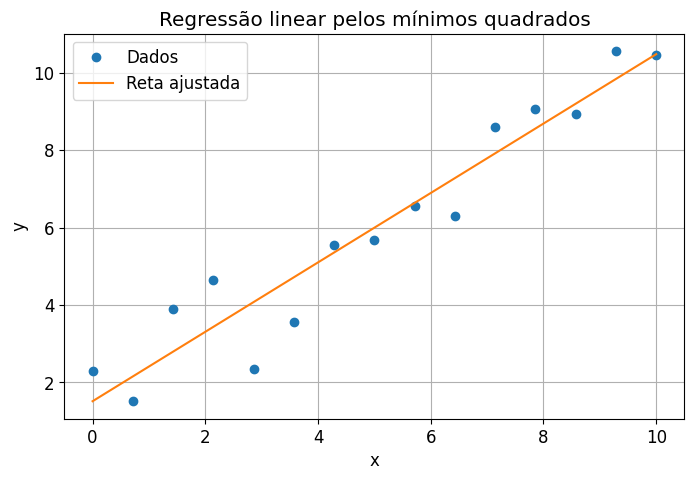

In [2]:
# Dados sinteticos: uma reta verdadeira + ruido de medicao
x = np.linspace(0, 10, 15)
a_true, b_true = 2.0, 0.8
y = a_true + b_true * x + rng.normal(0, 1.0, size=x.size)

# Ajuste "a mao", pelas formulas dos minimos quadrados
xbar, ybar = x.mean(), y.mean()
b_hat = np.sum((x - xbar) * (y - ybar)) / np.sum((x - xbar) ** 2)
a_hat = ybar - b_hat * xbar

# O mesmo com numpy (grau 1 = reta). polyfit devolve do maior grau para o menor.
b_np, a_np = np.polyfit(x, y, 1)

print(f"A mao:    a = {a_hat:.3f},  b = {b_hat:.3f}")
print(f"polyfit:  a = {a_np:.3f},  b = {b_np:.3f}")

plt.figure()
plt.plot(x, y, "o", label="Dados")
plt.plot(x, a_hat + b_hat * x, "-", label="Reta ajustada")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Regressão linear pelos mínimos quadrados")
plt.legend()
plt.show()

As duas contas batem: as fórmulas dos mínimos quadrados e o `np.polyfit` produzem exatamente a mesma reta. Atenção a um detalhe que costuma confundir: `polyfit(x, y, 1)` devolve os coeficientes **do maior grau para o menor** — primeiro a inclinação, depois o intercepto. Por isso lemos `b_np, a_np` nessa ordem.

## 5. O ajuste é bom? R² e RMSE

Achar a melhor reta não garante que ela seja *adequada*. Precisamos medir o quanto o modelo explica os dados. Duas métricas são onipresentes.

**RMSE (raiz do erro quadrático médio).** É o tamanho típico de um resíduo, na mesma unidade de $y$:

$$
\text{RMSE} = \sqrt{\frac{1}{n}\sum_{i=1}^{n} e_i^{\,2}}.
$$

Quanto menor, melhor. Um RMSE de $2$ significa que o modelo erra, em média, cerca de $2$ unidades.

**Coeficiente de determinação $R^2$.** Compara o erro do modelo com o de um "modelo bobo" que só chuta a média de $y$:

$$
R^2 = 1 - \frac{\sum (y_i-\hat{y}_i)^2}{\sum (y_i-\bar{y})^2}.
$$

$R^2=1$ é ajuste perfeito; $R^2=0$ significa que o modelo não é melhor que chutar a média; valores negativos são possíveis e indicam um ajuste pior ainda. Cuidado, porém: $R^2$ alto **não** prova que o modelo é o certo — só que ele acompanha bem *estes* dados.

R^2  = 0.9162
RMSE = 0.8370


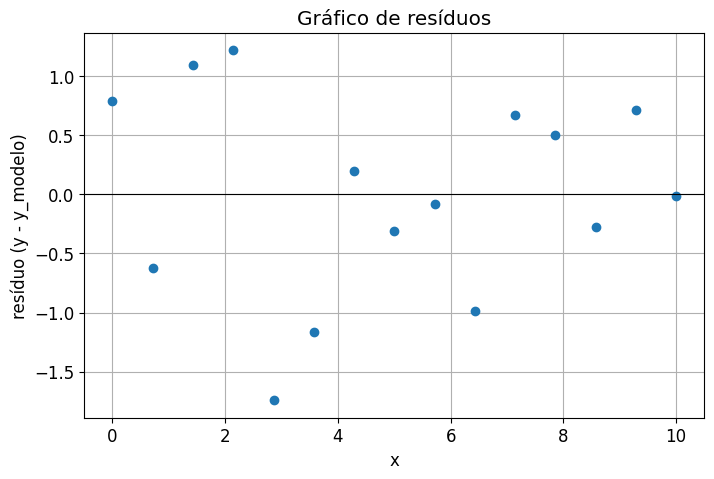

In [3]:
y_pred = a_hat + b_hat * x
res = y - y_pred                            # vetor de residuos

ss_res = np.sum(res ** 2)                   # soma dos quadrados dos residuos
ss_tot = np.sum((y - ybar) ** 2)            # variabilidade total dos dados
R2 = 1 - ss_res / ss_tot
rmse = np.sqrt(np.mean(res ** 2))

print(f"R^2  = {R2:.4f}")
print(f"RMSE = {rmse:.4f}")

plt.figure()
plt.plot(x, res, "o")
plt.axhline(0, color="black", linewidth=0.8)
plt.xlabel("x")
plt.ylabel("resíduo (y - y_modelo)")
plt.title("Gráfico de resíduos")
plt.show()

### Lendo o gráfico de resíduos

O gráfico de resíduos costuma revelar mais do que o $R^2$. A pergunta é: *os resíduos parecem aleatórios em torno de zero?*

- Se sim — uma nuvem sem padrão —, o modelo capturou a tendência e sobrou só o ruído. Bom sinal.
- Se aparece um **padrão** (uma curva, um "U", um leque que abre), é sinal de que o modelo deixou estrutura para trás: talvez a relação não seja realmente linear, ou o ruído não seja uniforme.

Resíduos são, muitas vezes, o melhor diagnóstico de que um modelo precisa ser trocado.

### Exercícios

1. Gere seus próprios dados de uma reta com mais ruído (aumente o desvio-padrão) e veja o que acontece com o $R^2$ e o RMSE.
2. Ajuste uma reta a dados que na verdade seguem uma parábola. Olhe o gráfico de resíduos — você consegue "ver" que a reta é inadequada?
3. Mostre, a partir das fórmulas, que a reta ajustada sempre passa por $(\bar{x}, \bar{y})$.

## 6. Um truque útil: linearizar antes de ajustar

Muitos modelos não lineares podem ser transformados em retas com um pouco de álgebra — e aí reaproveitamos toda a maquinaria da regressão linear. O exemplo clássico é o crescimento exponencial:

$$
y = y_0\,e^{kt}.
$$

Aplicando o logaritmo natural dos dois lados,

$$
\ln y = \underbrace{\ln y_0}_{a} + \underbrace{k}_{b}\,t.
$$

Em palavras: **se o crescimento é exponencial, o gráfico de $\ln y$ contra $t$ é uma reta**, cuja inclinação é $k$ e cujo intercepto é $\ln y_0$. Basta ajustar essa reta e desfazer o logaritmo.

Estimado:   y0 = 4.81,  k = 0.306
Verdadeiro: y0 = 5.00,  k = 0.300


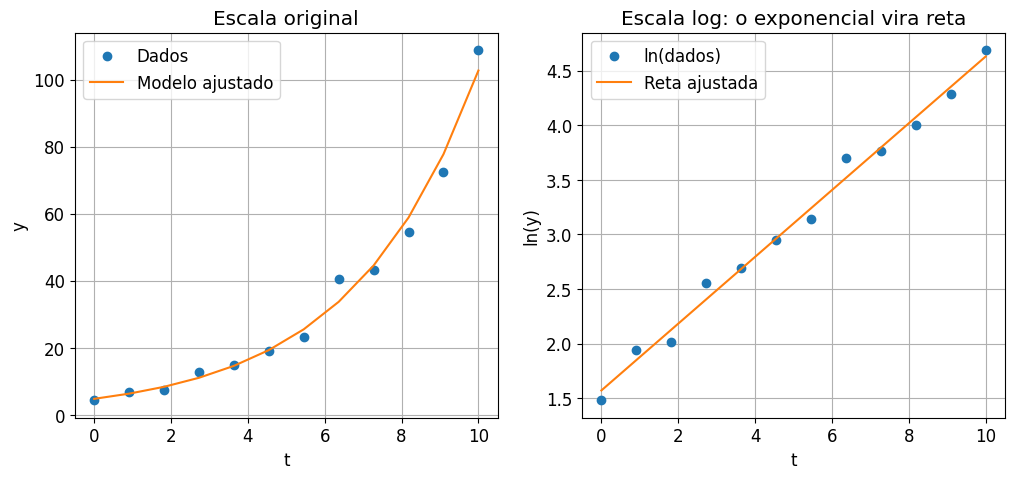

In [4]:
# Dados de um crescimento exponencial com ruido multiplicativo
t = np.linspace(0, 10, 12)
y0_true, k_true = 5.0, 0.3
y = y0_true * np.exp(k_true * t) * rng.lognormal(0, 0.15, size=t.size)

# Linearizacao: ln(y) = ln(y0) + k*t  ->  reta em (t, ln y)
log_y = np.log(y)
k_hat, ln_y0_hat = np.polyfit(t, log_y, 1)
y0_hat = np.exp(ln_y0_hat)

print(f"Estimado:   y0 = {y0_hat:.2f},  k = {k_hat:.3f}")
print(f"Verdadeiro: y0 = {y0_true:.2f},  k = {k_true:.3f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(t, y, "o", label="Dados")
ax1.plot(t, y0_hat * np.exp(k_hat * t), "-", label="Modelo ajustado")
ax1.set_xlabel("t")
ax1.set_ylabel("y")
ax1.set_title("Escala original")
ax1.legend()

ax2.plot(t, log_y, "o", label="ln(dados)")
ax2.plot(t, ln_y0_hat + k_hat * t, "-", label="Reta ajustada")
ax2.set_xlabel("t")
ax2.set_ylabel("ln(y)")
ax2.set_title("Escala log: o exponencial vira reta")
ax2.legend()

plt.show()

### A letra miúda da linearização

A linearização é prática, mas tem um preço que costuma ser esquecido: **ela distorce os erros**. Ao aplicar o logaritmo, comprimimos os valores grandes e esticamos os pequenos, então o ajuste passa a dar pesos diferentes aos pontos em relação à escala original. Minimizar os quadrados em $\ln y$ **não é** o mesmo que minimizá-los em $y$.

Por isso a linearização é ótima para uma estimativa rápida ou para um chute inicial, mas, quando a precisão importa, o correto é ajustar o modelo diretamente na escala original — com mínimos quadrados *não lineares*, o nosso próximo assunto.

## 7. Mínimos quadrados não lineares

Nem todo modelo se deixa linearizar — e, como vimos, mesmo quando se deixa, isso muda o problema. No caso geral, queremos minimizar

$$
S(\theta) = \sum_{i=1}^{n}\left(y_i - f(x_i;\theta)\right)^2,
$$

onde $f$ é o modelo (possivelmente bem não linear) e $\theta$ é o vetor de parâmetros. Agora **não há fórmula fechada**: a minimização é feita por um algoritmo *iterativo*, que parte de um chute inicial e o refina passo a passo, descendo o vale da função de custo.

No SciPy, a função `curve_fit` faz isso por nós. Precisamos fornecer:

- a função do modelo `f(x, *parametros)`;
- os dados `x` e `y`;
- um **chute inicial** `p0` para os parâmetros (importa mais do que parece — veja a seção de armadilhas).

Como bônus, a `curve_fit` devolve uma estimativa da **incerteza** de cada parâmetro, na forma de uma matriz de covariância.

r  =   0.466  ±  0.030
K  = 201.216  ±  1.751
N0 =  24.803  ±  3.033


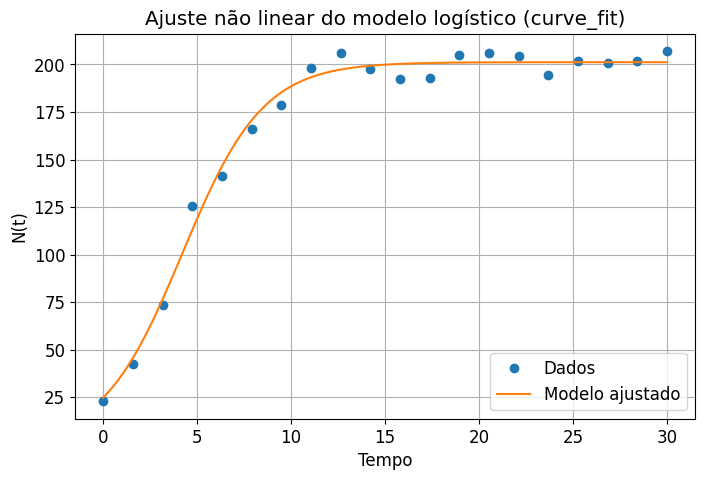

In [5]:
def logistica(t, r, K, N0):
    '''Solucao analitica do modelo logistico.'''
    return K / (1 + ((K - N0) / N0) * np.exp(-r * t))


t = np.linspace(0, 30, 20)
r_true, K_true, N0_true = 0.5, 200.0, 20.0
y = logistica(t, r_true, K_true, N0_true) + rng.normal(0, 8, size=t.size)

p0 = [0.2, 150, 10]                          # chute inicial: r, K, N0
popt, pcov = curve_fit(logistica, t, y, p0=p0)
perr = np.sqrt(np.diag(pcov))                # desvio-padrao de cada parametro

for nome, val, err in zip(["r ", "K ", "N0"], popt, perr):
    print(f"{nome} = {val:7.3f}  ±  {err:.3f}")

t_fino = np.linspace(0, 30, 300)
plt.figure()
plt.plot(t, y, "o", label="Dados")
plt.plot(t_fino, logistica(t_fino, *popt), "-", label="Modelo ajustado")
plt.xlabel("Tempo")
plt.ylabel("N(t)")
plt.title("Ajuste não linear do modelo logístico (curve_fit)")
plt.legend()
plt.show()

### A matriz de covariância e a incerteza dos parâmetros

Quando a `curve_fit` devolve `pcov`, ela está entregando a **matriz de covariância** dos parâmetros estimados — uma forma compacta de dizer *quanta incerteza* há em cada parâmetro e *o quanto eles estão amarrados entre si*.

Para um modelo com $p$ parâmetros $\theta = (\theta_1,\dots,\theta_p)$, a matriz de covariância $C$ é $p\times p$:

$$
C =
\begin{pmatrix}
\operatorname{Var}(\theta_1) & \operatorname{Cov}(\theta_1,\theta_2) & \cdots & \operatorname{Cov}(\theta_1,\theta_p) \\
\operatorname{Cov}(\theta_2,\theta_1) & \operatorname{Var}(\theta_2) & \cdots & \operatorname{Cov}(\theta_2,\theta_p) \\
\vdots & \vdots & \ddots & \vdots \\
\operatorname{Cov}(\theta_p,\theta_1) & \operatorname{Cov}(\theta_p,\theta_2) & \cdots & \operatorname{Var}(\theta_p)
\end{pmatrix}.
$$

Como ler essa matriz:

- **na diagonal** ficam as **variâncias**, $C_{ii}=\operatorname{Var}(\theta_i)$: o quanto cada parâmetro tende a oscilar se repetíssemos o experimento;
- **fora da diagonal** ficam as **covariâncias**, $C_{ij}=\operatorname{Cov}(\theta_i,\theta_j)$: se dois parâmetros variam juntos (um compensando o outro no ajuste);
- ela é **simétrica**, pois $C_{ij}=C_{ji}$.

**De onde ela vem.** No ajuste por mínimos quadrados, $C$ é estimada a partir da *sensibilidade* do modelo aos parâmetros — a matriz jacobiana $J$, cujas colunas dizem quanto a curva muda quando mexemos em cada parâmetro — e do tamanho do ruído $\hat{\sigma}^2$, estimado pelos próprios resíduos:

$$
C \approx \hat{\sigma}^2\,\bigl(J^{\top}J\bigr)^{-1},
\qquad
\hat{\sigma}^2 = \frac{1}{n-p}\sum_{i=1}^{n} e_i^{\,2}.
$$

A intuição: se a curva é **muito sensível** a um parâmetro, os dados o \"prendem\" bem e a variância fica pequena; se a curva quase não muda quando ele varia, o parâmetro fica mal determinado e a variância dispara.

**Como sai o desvio-padrão.** O desvio-padrão de cada parâmetro é simplesmente a **raiz quadrada da sua variância** — ou seja, a raiz dos elementos da diagonal:

$$
\sigma_{\theta_i} = \sqrt{C_{ii}}.
$$

É exatamente o que a linha `perr = np.sqrt(np.diag(pcov))` faz: `np.diag(pcov)` extrai a diagonal (as variâncias) e `np.sqrt` tira a raiz. Reportamos, então, cada parâmetro como $\hat{\theta}_i \pm \sigma_{\theta_i}$.

**Correlação entre parâmetros.** Normalizando a covariância pelos desvios obtemos a **correlação**

$$
\rho_{ij} = \frac{C_{ij}}{\sigma_{\theta_i}\,\sigma_{\theta_j}}, \qquad -1 \le \rho_{ij} \le 1.
$$

Valores próximos de $\pm 1$ são um alerta de **identificabilidade**: os dados não conseguem separar bem aqueles dois parâmetros, porque um compensa o efeito do outro. A célula abaixo mostra tudo isso de forma concreta.

In [6]:
# A matriz de covariancia devolvida pela curve_fit
print("Matriz de covariância (pcov):")
print(pcov)

# Desvio-padrao = raiz da diagonal (as variancias)
desvios = np.sqrt(np.diag(pcov))
print("\nDesvios-padrão (raiz da diagonal):")
for nome, s in zip(["r ", "K ", "N0"], desvios):
    print(f"  sigma_{nome} = {s:.4f}")

# Matriz de correlacao: covariancia normalizada pelos desvios
correlacao = pcov / np.outer(desvios, desvios)
print("\nMatriz de correlação (diagonal = 1):")
print(np.round(correlacao, 3))

Matriz de covariância (pcov):
[[ 8.85074850e-04 -1.85698802e-02 -7.98021393e-02]
 [-1.85698802e-02  3.06650880e+00  1.12449846e+00]
 [-7.98021393e-02  1.12449846e+00  9.19941767e+00]]

Desvios-padrão (raiz da diagonal):
  sigma_r  = 0.0298
  sigma_K  = 1.7511
  sigma_N0 = 3.0331

Matriz de correlação (diagonal = 1):
[[ 1.    -0.356 -0.884]
 [-0.356  1.     0.212]
 [-0.884  0.212  1.   ]]


### Enxergando o vale

Para deixar concreto o que o algoritmo faz, podemos congelar todos os parâmetros menos um e desenhar a função de custo. A curva abaixo mostra a soma dos quadrados dos resíduos em função de $r$ (com $K$ e $N_0$ nos valores verdadeiros). O ajuste nada mais é do que encontrar o fundo desse vale.

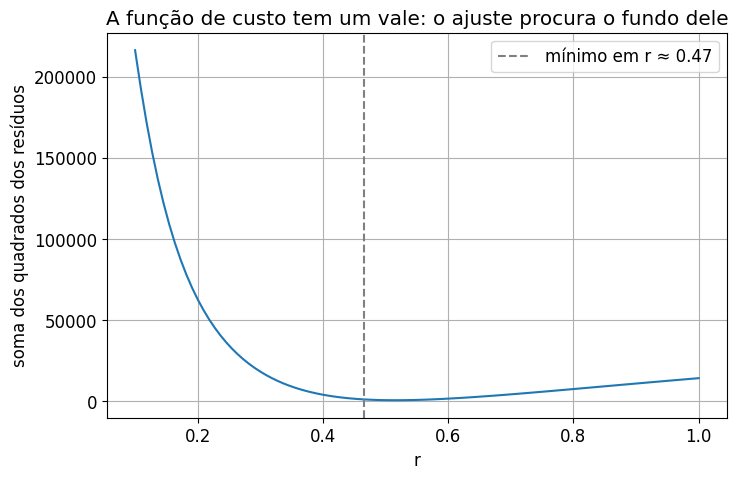

In [7]:
# Como o ajuste "enxerga" um parametro: varremos r e medimos o erro (SQR)
r_grid = np.linspace(0.1, 1.0, 100)
sqr = [np.sum((logistica(t, r, K_true, N0_true) - y) ** 2) for r in r_grid]

plt.figure()
plt.plot(r_grid, sqr)
plt.axvline(popt[0], linestyle="--", color="gray", label=f"mínimo em r ≈ {popt[0]:.2f}")
plt.xlabel("r")
plt.ylabel("soma dos quadrados dos resíduos")
plt.title("A função de custo tem um vale: o ajuste procura o fundo dele")
plt.legend()
plt.show()

## 8. O grande passo: ajustar uma EDO a dados

Até aqui, o modelo era uma fórmula explícita $f(x;\theta)$. Mas no Capítulo 1 muitos modelos **não têm solução analítica** — o biorreator de Monod é um exemplo. Como ajustar os parâmetros de uma EDO que só sabemos resolver numericamente?

A ideia é juntar as duas ferramentas dos capítulos:

1. dado um candidato a parâmetros, **resolvemos a EDO** com o `solve_ivp` (problema direto);
2. comparamos a solução numérica com os dados e calculamos os **resíduos**;
3. deixamos um otimizador **ajustar os parâmetros** para minimizar a soma dos quadrados.

O `scipy.optimize.least_squares` é feito sob medida para o passo 3: passamos a ele uma função que devolve o *vetor de resíduos*, e ele cuida da minimização. Note que a cada tentativa de parâmetros ele resolve a EDO de novo — é mais caro que ajustar uma fórmula, mas funciona para **qualquer** modelo do Capítulo 1.

r estimado = 0.510   (verdadeiro 0.5)
K estimado = 198.04   (verdadeiro 200)


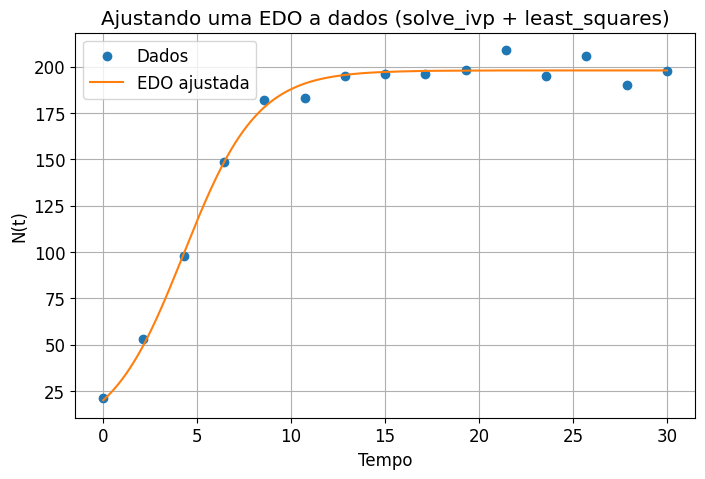

In [8]:
def modelo_logistico(t, y, r, K):
    '''dN/dt = r*N*(1 - N/K).'''
    return [r * y[0] * (1 - y[0] / K)]


def simular(r, K, N0, t_eval):
    '''Resolve a EDO e devolve N(t) nos tempos pedidos.'''
    sol = solve_ivp(modelo_logistico, (t_eval[0], t_eval[-1]), [N0],
                    args=(r, K), t_eval=t_eval)
    return sol.y[0]


# Dados sinteticos: geramos a partir da EDO e somamos ruido
t_dados = np.linspace(0, 30, 15)
N0 = 20.0
y_dados = simular(0.5, 200.0, N0, t_dados) + rng.normal(0, 6, size=t_dados.size)


def residuos(params):
    '''Vetor de residuos que o least_squares vai minimizar.'''
    r, K = params
    return simular(r, K, N0, t_dados) - y_dados


resultado = least_squares(residuos, x0=[0.2, 150.0])
r_hat, K_hat = resultado.x
print(f"r estimado = {r_hat:.3f}   (verdadeiro 0.5)")
print(f"K estimado = {K_hat:.2f}   (verdadeiro 200)")

t_fino = np.linspace(0, 30, 300)
plt.figure()
plt.plot(t_dados, y_dados, "o", label="Dados")
plt.plot(t_fino, simular(r_hat, K_hat, N0, t_fino), "-", label="EDO ajustada")
plt.xlabel("Tempo")
plt.ylabel("N(t)")
plt.title("Ajustando uma EDO a dados (solve_ivp + least_squares)")
plt.legend()
plt.show()

Os valores estimados caem bem perto dos verdadeiros, mesmo partindo de um chute distante e usando dados ruidosos. E o mais importante: **o método não usou em nenhum momento a solução analítica do logístico**. Exatamente o mesmo esqueleto serve para ajustar $\mu_{\max}$, $K_s$ e $Y_{X/S}$ do modelo de Monod, ou os parâmetros do presa-predador — basta trocar a função do modelo dentro de `simular`.

### Exercício

Adapte o código acima para ajustar o modelo de Monod (biorreator em batelada do Capítulo 1) a dados sintéticos de biomassa e substrato. Dica: gere os dados com `solve_ivp`, some ruído e, na função de resíduos, empilhe os erros das duas variáveis com `np.concatenate`.

## 9. Uma ponte para o Capítulo 3: mínimos quadrados e verossimilhança

Por que *quadrados*, afinal — só por conveniência? Há uma razão mais profunda. Suponha que cada medição seja o valor do modelo mais um ruído **gaussiano** independente:

$$
y_i = f(x_i;\theta) + \varepsilon_i, \qquad \varepsilon_i \sim \mathcal{N}(0,\sigma^2).
$$

A *verossimilhança* dos dados — a probabilidade de observá-los, dado $\theta$ — é o produto das gaussianas:

$$
L(\theta) \propto \prod_{i=1}^{n}\exp\!\left(-\frac{(y_i - f(x_i;\theta))^2}{2\sigma^2}\right).
$$

Maximizar $L$ é o mesmo que maximizar o seu logaritmo, e o logaritmo transforma o produto numa soma:

$$
\ln L(\theta) = \text{const} - \frac{1}{2\sigma^2}\sum_{i=1}^{n}\left(y_i - f(x_i;\theta)\right)^2.
$$

Olhe o último termo: maximizar a verossimilhança é **exatamente** minimizar a soma dos quadrados dos resíduos. Ou seja, sob a hipótese de ruído gaussiano, **mínimos quadrados = máxima verossimilhança**.

Essa equivalência é a porta de entrada do Capítulo 3. Lá, em vez de buscar um único "melhor" $\theta$, trataremos os parâmetros como **distribuições de probabilidade** e perguntaremos não só "qual o melhor valor?", mas "quão confiantes estamos nele?" — é a **calibração bayesiana**, com a verossimilhança no centro.

## 10. Boas práticas e armadilhas

Ajustar modelos é cheio de sutilezas. As mais comuns:

- **Chute inicial.** Para modelos não lineares, um `p0` ruim pode levar o otimizador a um *mínimo local* — um fundo de vale que não é o mais baixo. Use o que você sabe do problema (ordens de grandeza, valores típicos) para chutar bem. A linearização da Seção 6 dá ótimos chutes iniciais.
- **Identificabilidade.** Às vezes os dados simplesmente não contêm informação suficiente para separar dois parâmetros — eles se compensam. Incertezas enormes ou correlações altas na matriz de covariância são o sintoma. A solução costuma ser coletar dados mais informativos, não insistir no ajuste.
- **Sobreajuste (overfitting).** Um modelo com muitos parâmetros pode "decorar" o ruído e ter $R^2$ quase $1$ nos dados de treino, mas falhar ao prever dados novos. Mais parâmetros nem sempre é melhor — escolher *quantos* usar é tema do Capítulo 3 (seleção de modelos).
- **Escala dos parâmetros.** Quando os parâmetros têm ordens de grandeza muito diferentes, ajude o otimizador normalizando-os ou informando limites (`bounds`).
- **Sempre olhe o gráfico.** Métricas resumem; gráficos de ajuste e de resíduos revelam. Nunca confie num número sem ver a curva sobre os dados.

## 11. Mini-projeto — Estimando a taxa de crescimento de uma cultura

Você recebe medições de densidade celular de uma cultura ao longo de 48 horas (gere-as você mesmo com um modelo logístico mais ruído, como fizemos no capítulo).

**Tarefas.**

1. Faça o gráfico dos dados. A olho nu, estime $K$ (o patamar) e o instante de crescimento máximo.
2. Use a linearização do trecho inicial (quando o crescimento é quase exponencial) para obter um chute de $r$.
3. Ajuste o modelo logístico completo com `curve_fit`, partindo desses chutes.
4. Repita o ajuste resolvendo a EDO com `least_squares` e confira que os resultados batem.
5. Reporte os parâmetros com suas incertezas, o $R^2$ e o gráfico de resíduos.
6. Discuta: os dados foram suficientes para fixar bem todos os parâmetros? Algum deles ficou com incerteza grande?

## Glossário do capítulo

| Termo | Significado |
|---|---|
| Problema inverso | Estimar parâmetros a partir de dados e de uma forma de modelo |
| Resíduo | Diferença entre o dado e a previsão do modelo, $y_i-\hat{y}_i$ |
| Mínimos quadrados | Escolher parâmetros que minimizam a soma dos resíduos ao quadrado |
| Equações normais | Sistema que dá o ajuste linear em forma fechada |
| RMSE | Raiz do erro quadrático médio; erro típico, na unidade de $y$ |
| $R^2$ | Quanto da variabilidade dos dados o modelo explica |
| Linearização | Transformar um modelo não linear em reta antes de ajustar |
| `curve_fit` | Ajuste não linear iterativo do SciPy |
| `least_squares` | Otimizador de resíduos, útil para ajustar EDOs |
| Verossimilhança | Probabilidade dos dados dada uma escolha de parâmetros |
| Identificabilidade | Se os dados permitem ou não determinar um parâmetro |
| Sobreajuste | Modelo que decora o ruído e generaliza mal |

## Para fechar

Demos um passo importante: os parâmetros deixaram de vir de presente e passaram a ser **estimados a partir de medições**. O fio condutor foi simples e poderoso — definir resíduos, somá-los ao quadrado e minimizar — e se estendeu de uma reta até uma EDO completa, sempre com o mesmo espírito.

Também vimos que todo ajuste carrega uma pergunta embutida: *quão confiável é esse resultado?* As incertezas dos parâmetros, o gráfico de resíduos e os perigos de sobreajuste e de não identificabilidade já apontam para além de um único "melhor valor".

É exatamente aí que entra o **Capítulo 3**. Partindo da verossimilhança da Seção 9, vamos tratar os parâmetros como distribuições de probabilidade (calibração bayesiana) e construir critérios para **escolher entre modelos concorrentes** — não só ajustar um, mas decidir qual vale a pena.

## Referências e para saber mais

**Mínimos quadrados e regressão**
- MONTGOMERY, D. C.; PECK, E. A.; VINING, G. G. *Introduction to Linear Regression Analysis*. 5. ed. Hoboken: Wiley, 2012.
- SEBER, G. A. F.; WILD, C. J. *Nonlinear Regression*. Hoboken: Wiley, 2003.
- DRAPER, N. R.; SMITH, H. *Applied Regression Analysis*. 3. ed. New York: Wiley, 1998.
- STRUTZ, T. *Data Fitting and Uncertainty*. 2. ed. Wiesbaden: Springer Vieweg, 2016.

**Estimação de parâmetros e problemas inversos**
- BARD, Y. *Nonlinear Parameter Estimation*. New York: Academic Press, 1974.
- ASTER, R. C.; BORCHERS, B.; THURBER, C. H. *Parameter Estimation and Inverse Problems*. 3. ed. Amsterdam: Elsevier, 2018.
- TARANTOLA, A. *Inverse Problem Theory and Methods for Model Parameter Estimation*. Philadelphia: SIAM, 2005.

**Ponte para inferência estatística (Capítulo 3)**
- GELMAN, A. et al. *Bayesian Data Analysis*. 3. ed. Boca Raton: CRC Press, 2013.
- SIVIA, D. S.; SKILLING, J. *Data Analysis: A Bayesian Tutorial*. 2. ed. Oxford: Oxford University Press, 2006.

**Ferramentas computacionais**
- VIRTANEN, P. et al. SciPy 1.0: fundamental algorithms for scientific computing in Python. *Nature Methods*, v. 17, p. 261-272, 2020.
- HARRIS, C. R. et al. Array programming with NumPy. *Nature*, v. 585, p. 357-362, 2020.
- Documentação do `scipy.optimize`: <https://docs.scipy.org/doc/scipy/reference/optimize.html>